Výkon aerodynamického odporu (výpočet):  10.28 W


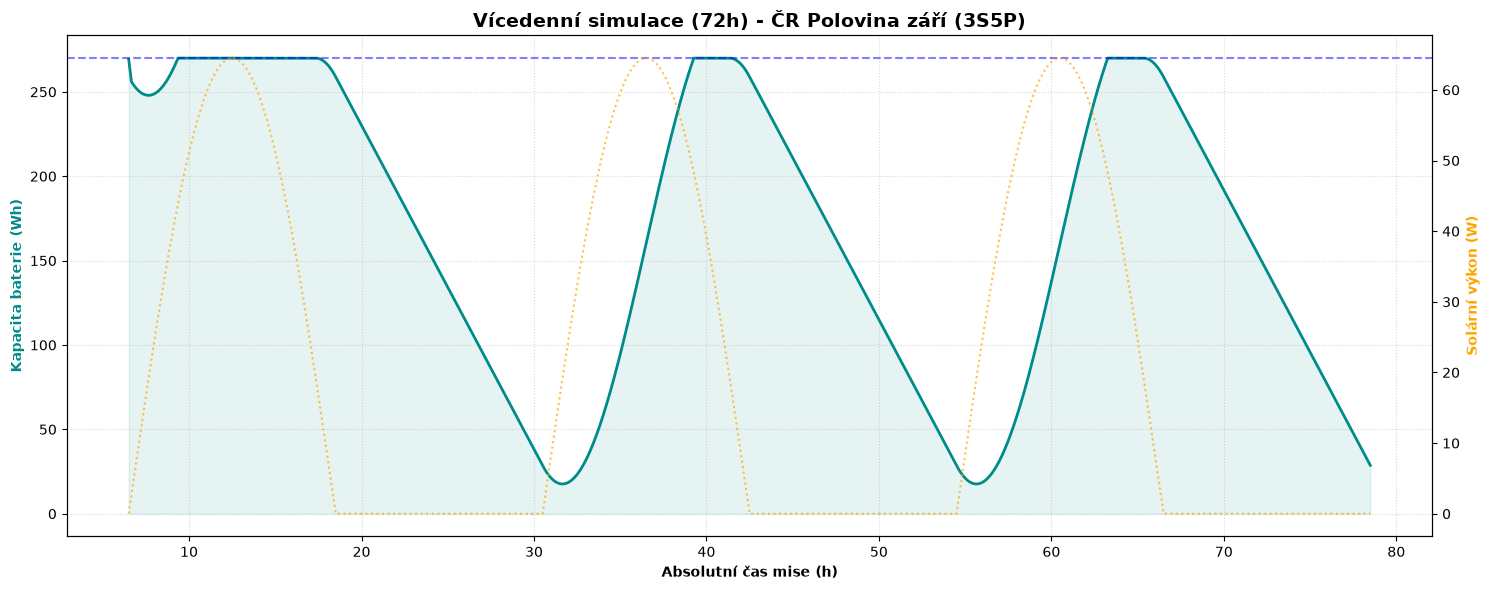

Doba letu: 72.0 hodin
Minimální úroveň energie v cyklu: 17.64 Wh
Průměrná spotřeba při cruise (výpočet): 19.20 W


In [1]:
import numpy as np
import matplotlib.pyplot as plt


battery_capacity_wh = 270

def compute_required_power(mass, wing_area, v_cruise, cd):
    rho = 1.225
    g = 9.81
    drag = 0.5 * rho * (v_cruise**2) * wing_area * cd
    p_aero = drag * v_cruise
    print(f"Výkon aerodynamického odporu (výpočet):  {p_aero:.2f} W")
    eta_motor, eta_prop = 0.83, 0.70
    return (p_aero / (eta_motor * eta_prop)) + 1.5

p_cruise_computed = compute_required_power(3.25, 0.58, 9.92,  0.02965)

dt = 1 / 120  
total_hours = 72
start_hour = 6.5 
time_axis = np.arange(start_hour, start_hour + total_hours, dt)

soc_history = []
solar_power_history = []
battery_soc = battery_capacity_wh
actual_time_elapsed = []

# Specifikace pro září v ČR
sunrise = 6.5
sunset = 18.5
p_peak_solar = 64.5 # Odhad špičkového výkonu 22 článků při ideálním osvitu

for t in time_axis:
    t_day = t % 24

    # Sinusový model solárního výkonu (plynulý přechod)
    if sunrise <= t_day <= sunset:
        day_progress = (t_day - sunrise) / (sunset - sunrise)
        p_solar = p_peak_solar * np.sin(np.pi * day_progress)
    else:
        p_solar = 0.0

    if start_hour <= t < start_hour + 0.166: 
        current_consumption = 85.0
    else:
        current_consumption = p_cruise_computed

    p_net = p_solar - current_consumption
    battery_soc += p_net * dt

    # Limity a ochrana
    if battery_soc > battery_capacity_wh:
        battery_soc = battery_capacity_wh

    soc_history.append(battery_soc)
    solar_power_history.append(p_solar)
    actual_time_elapsed.append(t)

    if battery_soc <= 0:
        print(f"!!! MISSION TERMINATED: Baterie vybita v čase {t:.2f} h !!!")
        break

# --- VYKRESLENÍ GRAFU ---
fig, ax1 = plt.subplots(figsize=(15, 6))
ax1.set_xlabel('Absolutní čas mise (h)', fontweight='bold')
ax1.set_ylabel('Kapacita baterie (Wh)', color='darkcyan', fontweight='bold')
ax1.plot(actual_time_elapsed, soc_history, color='darkcyan', linewidth=2, label='Kapacita baterie')
ax1.fill_between(actual_time_elapsed, 0, soc_history, color='darkcyan', alpha=0.1)
ax1.axhline(battery_capacity_wh, color='blue', linestyle='--', alpha=0.5, label='Max kapacita')

ax2 = ax1.twinx()
ax2.set_ylabel('Solární výkon (W)', color='orange', fontweight='bold')
ax2.plot(actual_time_elapsed, solar_power_history, color='orange', linestyle=':', alpha=0.7, label='Solární výkon (Sinus)')

plt.title(f'Vícedenní simulace (72h) - ČR Polovina září (3S5P)', fontsize=14, fontweight='bold')
ax1.grid(True, which='both', linestyle=':', alpha=0.5)
fig.tight_layout()
plt.show()

print(f"Doba letu: {actual_time_elapsed[-1] - actual_time_elapsed[0]:.1f} hodin")
print(f"Minimální úroveň energie v cyklu: {min(soc_history):.2f} Wh")
print(f"Průměrná spotřeba při cruise (výpočet): {p_cruise_computed:.2f} W")